# Loan Portfolio – Exploratory Data Analysis
**Author:** Chaoda Jiang | MS Business Analytics, UC San Diego

**Portfolio:** 1,464 loans originated 2025-01-01 to 2026-04-30

**Goals:**
1. Understand portfolio composition (amount, rate, term)
2. Analyze loan status distribution and lifecycle
3. Identify regional and source-system concentration risk
4. Examine overdue aging and repayment behavior
5. Connect data quality findings to business risk

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from pathlib import Path

BASE_DIR = Path().resolve().parent
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
PALETTE = {"active": "#4C72B0", "closed": "#55A868", "defaulted": "#FFC107", "written_off": "#DD2222"}

loans     = pd.read_csv(BASE_DIR / "data/raw/loan_transactions.csv", parse_dates=["transaction_date"])
schedule  = pd.read_csv(BASE_DIR / "data/raw/repayment_schedule.csv")
repay     = pd.read_csv(BASE_DIR / "data/raw/repayment_transactions.csv", parse_dates=["transaction_date"])
transfers = pd.read_csv(BASE_DIR / "data/raw/loan_transfers.csv")

print(f"Loans: {len(loans):,} | Schedule rows: {len(schedule):,} | Repay txns: {len(repay):,} | Transfers: {len(transfers):,}")
print(f"Date range: {loans['transaction_date'].min().date()} to {loans['transaction_date'].max().date()}")

Loans: 1,464 | Schedule rows: 27,762 | Repay txns: 9,928 | Transfers: 153
Date range: 2025-01-01 to 2026-04-30


## 1. Portfolio Composition

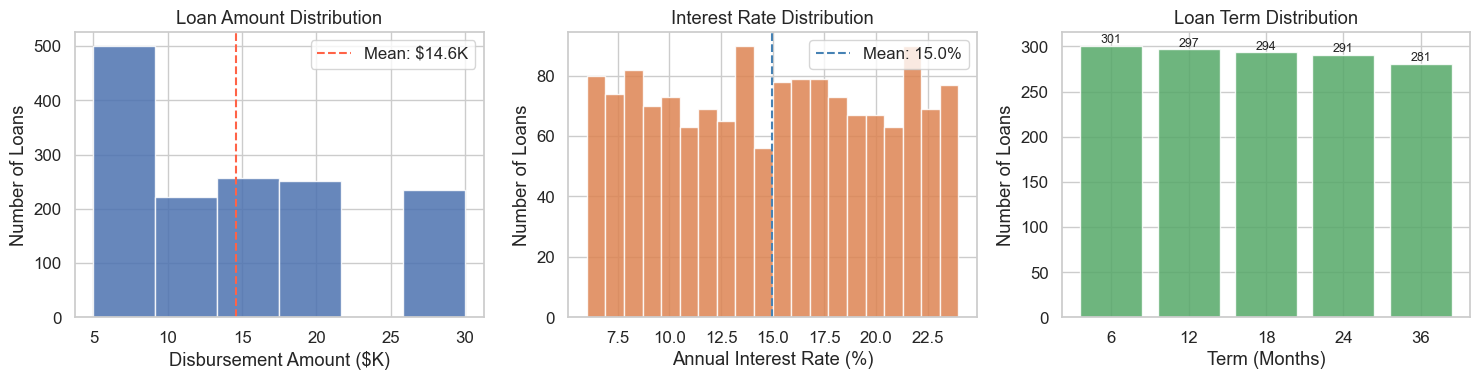


Portfolio Insight:
- Average loan size is $14,612, indicating a mid-market consumer lending profile.
- Average interest rate of 15.0% is above prime, reflecting risk-adjusted pricing.
- The most common loan term is 6 months.
- Total portfolio exposure: $21,392,000 across 1,464 loans.


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(loans["disbursement_amount"]/1000, bins=6, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[0].axvline(loans["disbursement_amount"].mean()/1000, color="tomato", linestyle="--", linewidth=1.5,
                label=f"Mean: ${loans['disbursement_amount'].mean()/1000:.1f}K")
axes[0].set_title("Loan Amount Distribution")
axes[0].set_xlabel("Disbursement Amount ($K)")
axes[0].set_ylabel("Number of Loans")
axes[0].legend()

axes[1].hist(loans["interest_rate"]*100, bins=20, color="#DD8452", edgecolor="white", alpha=0.85)
axes[1].axvline(loans["interest_rate"].mean()*100, color="steelblue", linestyle="--", linewidth=1.5,
                label=f"Mean: {loans['interest_rate'].mean()*100:.1f}%")
axes[1].set_title("Interest Rate Distribution")
axes[1].set_xlabel("Annual Interest Rate (%)")
axes[1].set_ylabel("Number of Loans")
axes[1].legend()

term_counts = loans["term_months"].value_counts().sort_index()
axes[2].bar(term_counts.index.astype(str), term_counts.values, color="#55A868", edgecolor="white", alpha=0.85)
for i, v in enumerate(term_counts.values):
    axes[2].text(i, v + 3, str(v), ha="center", fontsize=9)
axes[2].set_title("Loan Term Distribution")
axes[2].set_xlabel("Term (Months)")
axes[2].set_ylabel("Number of Loans")

plt.tight_layout()
plt.savefig(BASE_DIR / "reports/fig1_portfolio_composition.png", dpi=150, bbox_inches="tight")
plt.show()

avg_amount = loans["disbursement_amount"].mean()
avg_rate   = loans["interest_rate"].mean() * 100
top_term   = loans["term_months"].mode()[0]
total_exp  = loans["disbursement_amount"].sum()
print("\nPortfolio Insight:")
print(f"- Average loan size is ${avg_amount:,.0f}, indicating a mid-market consumer lending profile.")
print(f"- Average interest rate of {avg_rate:.1f}% is above prime, reflecting risk-adjusted pricing.")
print(f"- The most common loan term is {top_term} months.")
print(f"- Total portfolio exposure: ${total_exp:,.0f} across {len(loans):,} loans.")

## 2. Loan Status Distribution & Lifecycle

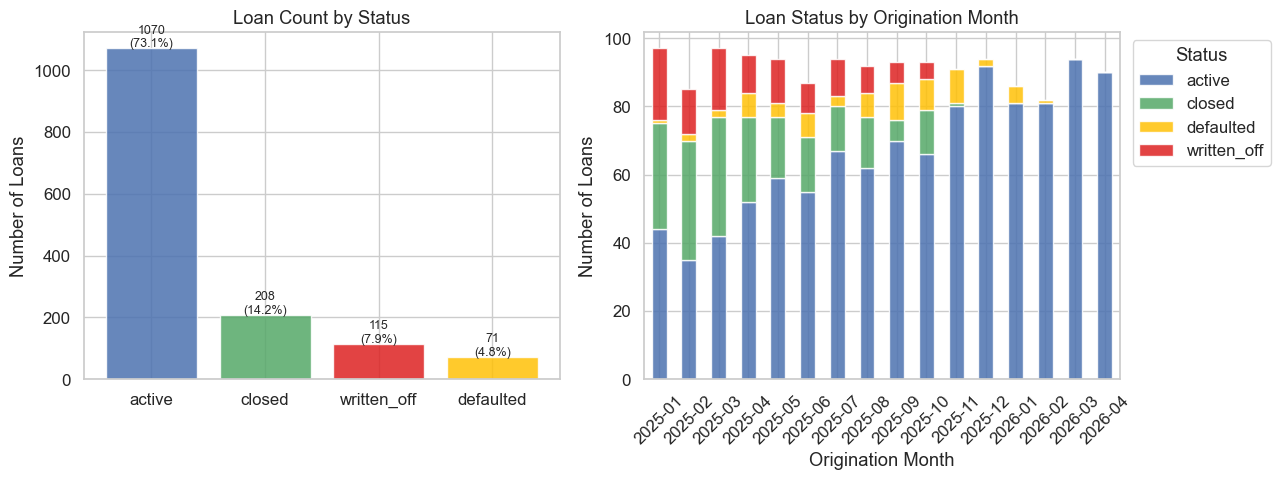


Lifecycle Insight:
- 12.7% of loans (186) are defaulted or written-off.
- Written-off loans account for $1,370,738 in charge-offs (6.4% of disbursed capital).
- 14.2% of loans have been fully repaid (closed).
- Early-vintage loans show higher written-off rates, consistent with the 120-day charge-off timeline.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

status_counts = loans["loan_status"].value_counts()
colors = [PALETTE[s] for s in status_counts.index]
bars = axes[0].bar(status_counts.index, status_counts.values, color=colors, edgecolor="white", alpha=0.85)
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 f"{val}\n({val/len(loans)*100:.1f}%)", ha="center", fontsize=9)
axes[0].set_title("Loan Count by Status")
axes[0].set_ylabel("Number of Loans")

loans["month"] = loans["transaction_date"].dt.to_period("M")
monthly_status = loans.groupby(["month","loan_status"]).size().unstack(fill_value=0)
monthly_status.index = monthly_status.index.astype(str)
monthly_status.plot(kind="bar", stacked=True, ax=axes[1],
                    color=[PALETTE.get(c,"#999") for c in monthly_status.columns],
                    edgecolor="white", alpha=0.85)
axes[1].set_title("Loan Status by Origination Month")
axes[1].set_xlabel("Origination Month")
axes[1].set_ylabel("Number of Loans")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Status", bbox_to_anchor=(1.01,1), loc="upper left")

plt.tight_layout()
plt.savefig(BASE_DIR / "reports/fig2_loan_status.png", dpi=150, bbox_inches="tight")
plt.show()

bad_count = loans["loan_status"].isin(["defaulted","written_off"]).sum()
bad_pct   = bad_count / len(loans) * 100
wo_amount = loans[loans["loan_status"]=="written_off"]["charge_off_amount"].sum()
wo_pct    = wo_amount / loans["disbursement_amount"].sum() * 100
closed_pct= (loans["loan_status"]=="closed").sum() / len(loans) * 100
print("\nLifecycle Insight:")
print(f"- {bad_pct:.1f}% of loans ({bad_count}) are defaulted or written-off.")
print(f"- Written-off loans account for ${wo_amount:,.0f} in charge-offs ({wo_pct:.1f}% of disbursed capital).")
print(f"- {closed_pct:.1f}% of loans have been fully repaid (closed).")
print("- Early-vintage loans show higher written-off rates, consistent with the 120-day charge-off timeline.")

## 3. Regional & Source System Concentration

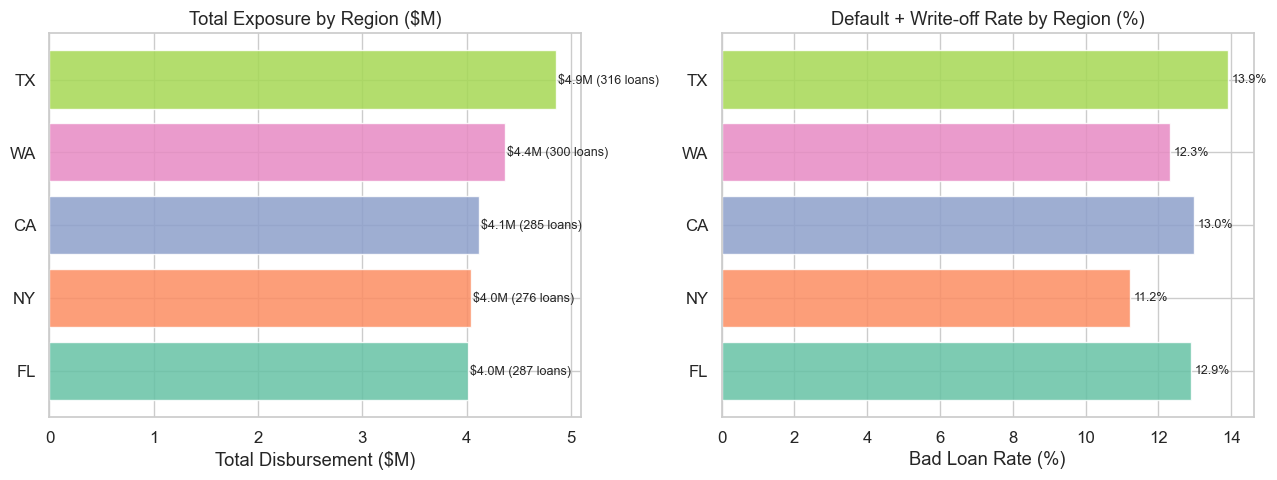


Regional Insight:
- TX has the highest total exposure at $4.9M.
- TX has the highest bad loan rate at 13.9%.
- NY shows the strongest credit performance at 11.2% bad loan rate.
- Geographic diversification across 5 states limits single-region concentration risk.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

region_stats = loans.groupby("region").agg(
    loan_count=("loan_id","count"),
    total_exposure=("disbursement_amount","sum"),
    bad_rate=("loan_status", lambda x: x.isin(["defaulted","written_off"]).mean())
).reset_index().sort_values("total_exposure", ascending=True)

REGION_COLORS = sns.color_palette("Set2", len(region_stats))

axes[0].barh(region_stats["region"], region_stats["total_exposure"]/1e6,
             color=REGION_COLORS, edgecolor="white", alpha=0.85)
for i, (exp, cnt) in enumerate(zip(region_stats["total_exposure"], region_stats["loan_count"])):
    axes[0].text(exp/1e6+0.02, i, f"${exp/1e6:.1f}M ({cnt} loans)", va="center", fontsize=9)
axes[0].set_title("Total Exposure by Region ($M)")
axes[0].set_xlabel("Total Disbursement ($M)")

axes[1].barh(region_stats["region"], region_stats["bad_rate"]*100,
             color=REGION_COLORS, edgecolor="white", alpha=0.85)
for i, r in enumerate(region_stats["bad_rate"]):
    axes[1].text(r*100+0.1, i, f"{r*100:.1f}%", va="center", fontsize=9)
axes[1].set_title("Default + Write-off Rate by Region (%)")
axes[1].set_xlabel("Bad Loan Rate (%)")

plt.tight_layout()
plt.savefig(BASE_DIR / "reports/fig3_regional_exposure.png", dpi=150, bbox_inches="tight")
plt.show()

top_r   = region_stats.sort_values("total_exposure", ascending=False).iloc[0]
worst_r = region_stats.sort_values("bad_rate", ascending=False).iloc[0]
best_r  = region_stats.sort_values("bad_rate").iloc[0]
print("\nRegional Insight:")
print(f"- {top_r['region']} has the highest total exposure at ${top_r['total_exposure']/1e6:.1f}M.")
print(f"- {worst_r['region']} has the highest bad loan rate at {worst_r['bad_rate']*100:.1f}%.")
print(f"- {best_r['region']} shows the strongest credit performance at {best_r['bad_rate']*100:.1f}% bad loan rate.")
print("- Geographic diversification across 5 states limits single-region concentration risk.")

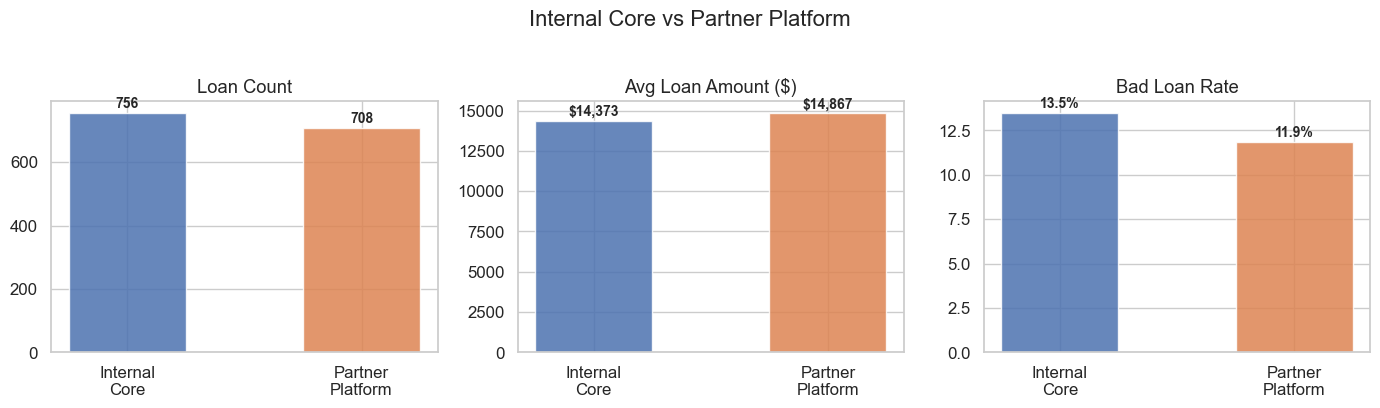


Source System Insight:
- Internal Core has a higher bad loan rate (13.5%) vs Partner Platform (11.9%), a 1.6pp difference.
- Partner loans average $14,867 vs $14,373 for internal.
- Recommendation: Apply stricter validation and enhanced monitoring for the higher-risk origination channel.


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
COLORS = {"internal_core": "#4C72B0", "partner_platform": "#DD8452"}

source_stats = loans.groupby("source_system").agg(
    loan_count=("loan_id","count"),
    avg_amount=("disbursement_amount","mean"),
    bad_rate=("loan_status", lambda x: x.isin(["defaulted","written_off"]).mean())
).reset_index()

for ax, (col, title, fmt) in zip(axes, [
    ("loan_count","Loan Count",""),
    ("avg_amount","Avg Loan Amount ($)","$"),
    ("bad_rate","Bad Loan Rate","%")
]):
    vals = source_stats[col] * (100 if fmt=="%" else 1)
    bars = ax.bar(source_stats["source_system"], vals,
                  color=[COLORS[s] for s in source_stats["source_system"]],
                  edgecolor="white", alpha=0.85, width=0.5)
    ax.set_title(title)
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(["Internal\nCore","Partner\nPlatform"])
    for bar, val in zip(bars, vals):
        label = f"${val:,.0f}" if fmt=="$" else f"{val:.1f}%" if fmt=="%" else str(int(val))
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+vals.max()*0.02,
                label, ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Internal Core vs Partner Platform", y=1.02)
plt.tight_layout()
plt.savefig(BASE_DIR / "reports/fig4_source_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

ic          = source_stats[source_stats["source_system"]=="internal_core"].iloc[0]
pp          = source_stats[source_stats["source_system"]=="partner_platform"].iloc[0]
higher_risk = source_stats.sort_values("bad_rate", ascending=False).iloc[0]
lower_risk  = source_stats.sort_values("bad_rate").iloc[0]
diff        = abs(pp["bad_rate"] - ic["bad_rate"]) * 100
print("\nSource System Insight:")
print(f"- {higher_risk['source_system'].replace('_',' ').title()} has a higher bad loan rate ({higher_risk['bad_rate']*100:.1f}%) vs {lower_risk['source_system'].replace('_',' ').title()} ({lower_risk['bad_rate']*100:.1f}%), a {diff:.1f}pp difference.")
print(f"- Partner loans average ${pp['avg_amount']:,.0f} vs ${ic['avg_amount']:,.0f} for internal.")
print("- Recommendation: Apply stricter validation and enhanced monitoring for the higher-risk origination channel.")

## 4. Overdue Aging Analysis

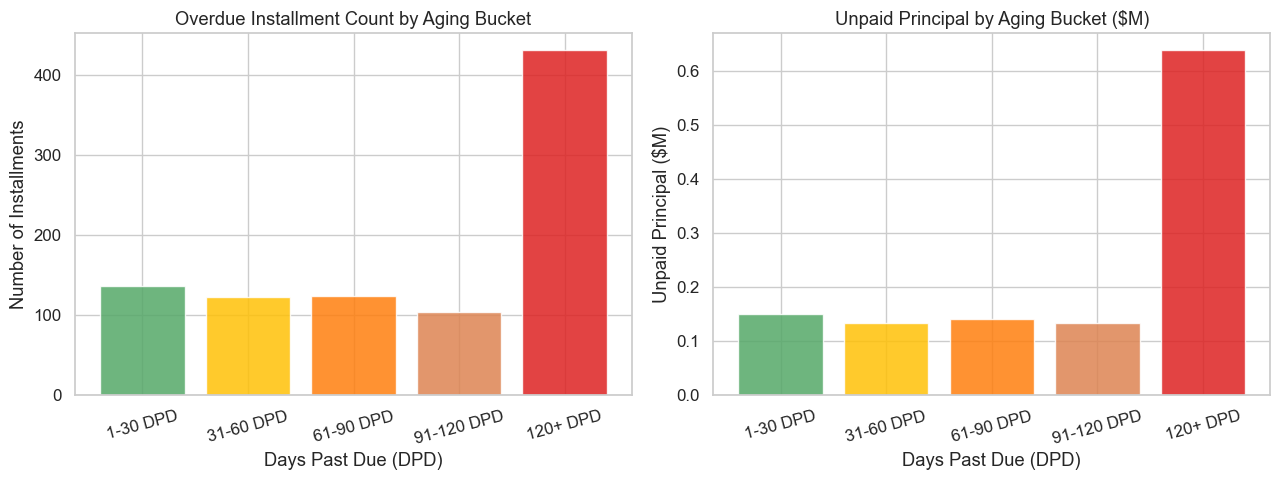


Overdue Aging Insight:
- Total overdue principal: $1,192,861 across 917 installments.
- Overdue interest accrued: $118,999 at 1.5x standard rate.
- 53.5% of overdue principal is in the 120+ DPD bucket — near-certain credit loss.
- Early-stage delinquency (1-30 DPD) should be prioritized for outreach and restructuring.


In [6]:
overdue = schedule[schedule["installment_overdue_flag"]==1].copy()
overdue = overdue.merge(loans[["loan_id","loan_status"]], on="loan_id", how="left")

def aging_bucket(d):
    if d<=30:    return "1-30 DPD"
    elif d<=60:  return "31-60 DPD"
    elif d<=90:  return "61-90 DPD"
    elif d<=120: return "91-120 DPD"
    else:        return "120+ DPD"

overdue["aging"] = overdue["overdue_days"].apply(aging_bucket)
bucket_order  = ["1-30 DPD","31-60 DPD","61-90 DPD","91-120 DPD","120+ DPD"]
BUCKET_COLORS = ["#55A868","#FFC107","#FF7F0E","#DD8452","#DD2222"]

aging_stats = overdue.groupby("aging").agg(
    installment_count=("loan_id","count"),
    unpaid_principal=("due_principal","sum"),
    overdue_interest=("overdue_interest_due","sum")
).reindex(bucket_order).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(aging_stats.index, aging_stats["installment_count"],
            color=BUCKET_COLORS, edgecolor="white", alpha=0.85)
axes[0].set_title("Overdue Installment Count by Aging Bucket")
axes[0].set_xlabel("Days Past Due (DPD)")
axes[0].set_ylabel("Number of Installments")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(aging_stats.index, aging_stats["unpaid_principal"]/1e6,
            color=BUCKET_COLORS, edgecolor="white", alpha=0.85)
axes[1].set_title("Unpaid Principal by Aging Bucket ($M)")
axes[1].set_xlabel("Days Past Due (DPD)")
axes[1].set_ylabel("Unpaid Principal ($M)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(BASE_DIR / "reports/fig5_overdue_aging.png", dpi=150, bbox_inches="tight")
plt.show()

tot_p  = aging_stats["unpaid_principal"].sum()
tot_i  = aging_stats["overdue_interest"].sum()
sev_pct= aging_stats.loc["120+ DPD","unpaid_principal"] / tot_p * 100 if tot_p>0 else 0
print("\nOverdue Aging Insight:")
print(f"- Total overdue principal: ${tot_p:,.0f} across {int(aging_stats['installment_count'].sum()):,} installments.")
print(f"- Overdue interest accrued: ${tot_i:,.0f} at 1.5x standard rate.")
print(f"- {sev_pct:.1f}% of overdue principal is in the 120+ DPD bucket — near-certain credit loss.")
print("- Early-stage delinquency (1-30 DPD) should be prioritized for outreach and restructuring.")

## 5. Repayment Behavior

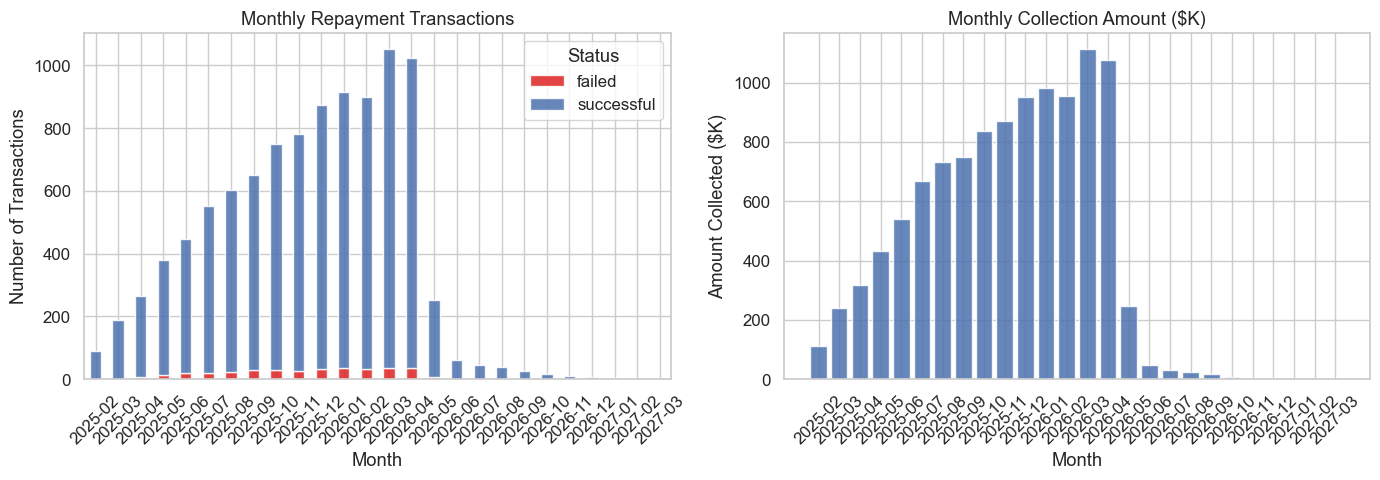


Repayment Insight:
- 9,574 successful payments collected $10,964,004 total.
- Payment failure rate: 3.6% (354 failed transactions).
- Monthly collection volumes grow with portfolio seasoning as more loans reach repayment schedules.
- Failed payments are concentrated in defaulted/written-off cohorts, confirming predictive value for credit models.


In [7]:
repay["month"] = repay["transaction_date"].dt.to_period("M")
monthly = repay.groupby(["month","payment_status"]).size().unstack(fill_value=0)
monthly.index = monthly.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monthly.plot(kind="bar", stacked=True, ax=axes[0],
             color={"successful":"#4C72B0","failed":"#DD2222"},
             edgecolor="white", alpha=0.85)
axes[0].set_title("Monthly Repayment Transactions")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Transactions")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend(title="Status")

monthly_amt = repay[repay["payment_status"]=="successful"].groupby("month")["repayment_total_amount"].sum()
monthly_amt.index = monthly_amt.index.astype(str)
axes[1].bar(monthly_amt.index, monthly_amt.values/1e3, color="#4C72B0", edgecolor="white", alpha=0.85)
axes[1].set_title("Monthly Collection Amount ($K)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Amount Collected ($K)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(BASE_DIR / "reports/fig6_repayment_behavior.png", dpi=150, bbox_inches="tight")
plt.show()

ok   = (repay["payment_status"]=="successful").sum()
fail = (repay["payment_status"]=="failed").sum()
coll = repay[repay["payment_status"]=="successful"]["repayment_total_amount"].sum()
print("\nRepayment Insight:")
print(f"- {ok:,} successful payments collected ${coll:,.0f} total.")
print(f"- Payment failure rate: {fail/(ok+fail)*100:.1f}% ({fail:,} failed transactions).")
print("- Monthly collection volumes grow with portfolio seasoning as more loans reach repayment schedules.")
print("- Failed payments are concentrated in defaulted/written-off cohorts, confirming predictive value for credit models.")

## 6. Asset Transfer Analysis

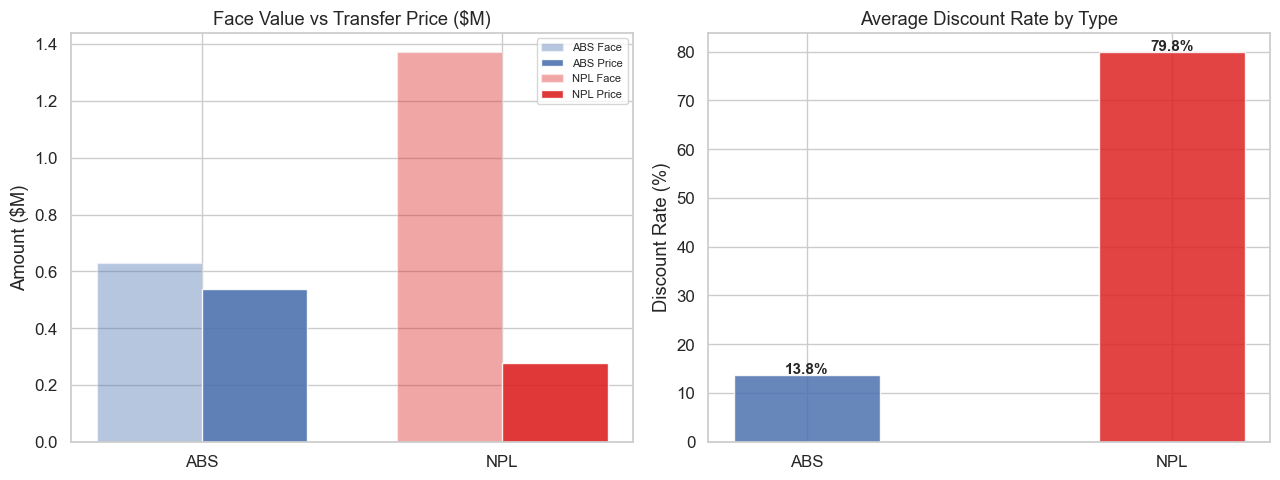


Asset Transfer Insight:
- Total realized loss on transfers: $1,183,992.
- ABS: 38 transfers, avg discount 13.8%.
- NPL: 115 transfers, avg discount 79.8%.
- Transfers convert illiquid non-performing loans to cash, reducing balance sheet risk.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

transfer_stats = transfers.groupby("transfer_type").agg(
    count=("transfer_id","count"),
    total_face=("face_value","sum"),
    total_price=("transfer_price","sum"),
    avg_discount=("discount_rate","mean")
).reset_index()

type_colors = {"NPL":"#DD2222","ABS":"#4C72B0"}
x = np.arange(len(transfer_stats))
w = 0.35
for i, row in transfer_stats.iterrows():
    c = type_colors[row["transfer_type"]]
    axes[0].bar(x[i]-w/2, row["total_face"]/1e6,   w, color=c, alpha=0.4, edgecolor="white", label=f"{row['transfer_type']} Face")
    axes[0].bar(x[i]+w/2, row["total_price"]/1e6,  w, color=c, alpha=0.9, edgecolor="white", label=f"{row['transfer_type']} Price")
axes[0].set_xticks(x)
axes[0].set_xticklabels(transfer_stats["transfer_type"])
axes[0].set_title("Face Value vs Transfer Price ($M)")
axes[0].set_ylabel("Amount ($M)")
axes[0].legend(fontsize=8)

bars = axes[1].bar(transfer_stats["transfer_type"], transfer_stats["avg_discount"]*100,
                   color=[type_colors[t] for t in transfer_stats["transfer_type"]],
                   edgecolor="white", alpha=0.85, width=0.4)
for bar, val in zip(bars, transfer_stats["avg_discount"]):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f"{val*100:.1f}%", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Average Discount Rate by Type")
axes[1].set_ylabel("Discount Rate (%)")

plt.tight_layout()
plt.savefig(BASE_DIR / "reports/fig7_transfer_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

total_loss = transfers["face_value"].sum() - transfers["transfer_price"].sum()
print("\nAsset Transfer Insight:")
print(f"- Total realized loss on transfers: ${total_loss:,.0f}.")
for _, row in transfer_stats.iterrows():
    print(f"- {row['transfer_type']}: {int(row['count'])} transfers, avg discount {row['avg_discount']*100:.1f}%.")
print("- Transfers convert illiquid non-performing loans to cash, reducing balance sheet risk.")

## 7. Data Quality Integration

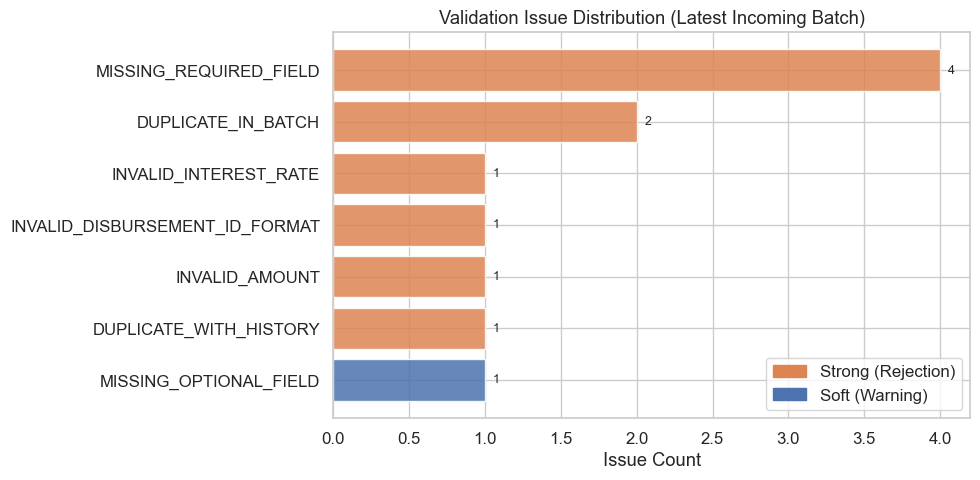


Data Quality Insight:
- 10 strong errors detected in the latest incoming batch.
- Most frequent issue: MISSING_REQUIRED_FIELD — direct transaction integrity risk if undetected.
- Upstream data capture controls should be strengthened to reduce re-submission cycles.
- Soft warnings (e.g. missing region) are non-blocking but reduce downstream analytics quality.


In [9]:
try:
    from matplotlib.patches import Patch
    error_log = pd.read_csv(BASE_DIR / "data/rejected/validation_error_log.csv")
    issue_counts = error_log.groupby(["rule_type","error_code"]).size().reset_index(name="count").sort_values("count", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 5))
    colors_dq = ["#DD8452" if r=="strong" else "#4C72B0" for r in issue_counts["rule_type"]]
    ax.barh(issue_counts["error_code"], issue_counts["count"], color=colors_dq, edgecolor="white", alpha=0.85)
    for bar, val in zip(ax.patches, issue_counts["count"]):
        ax.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2, str(val), va="center", fontsize=9)
    ax.legend(handles=[Patch(color="#DD8452",label="Strong (Rejection)"),Patch(color="#4C72B0",label="Soft (Warning)")])
    ax.set_title("Validation Issue Distribution (Latest Incoming Batch)")
    ax.set_xlabel("Issue Count")
    plt.tight_layout()
    plt.savefig(BASE_DIR / "reports/fig8_validation_errors.png", dpi=150, bbox_inches="tight")
    plt.show()

    strong    = error_log[error_log["rule_type"]=="strong"]
    top_issue = strong["error_code"].value_counts().index[0] if len(strong)>0 else "N/A"
    print("\nData Quality Insight:")
    print(f"- {len(strong)} strong errors detected in the latest incoming batch.")
    print(f"- Most frequent issue: {top_issue} — direct transaction integrity risk if undetected.")
    print("- Upstream data capture controls should be strengthened to reduce re-submission cycles.")
    print("- Soft warnings (e.g. missing region) are non-blocking but reduce downstream analytics quality.")
except FileNotFoundError:
    print("Run validation_pipeline.py first to generate error logs.")

## Key EDA Findings

| Dimension | Finding | Business Implication |
|---|---|---|
| Portfolio size | 1,464 loans, $21.4M total exposure | Mid-market consumer lending scale |
| Average loan | $14,612 at 15.0% APR | Risk-adjusted above-prime pricing |
| Credit quality | 12.7% bad loan rate (defaulted + written-off) | Within consumer lending norms; requires monitoring |
| Charge-off rate | 6.4% of disbursed capital written off | Benchmark: industry average ~5-8% for unsecured consumer |
| Geographic risk | TX highest exposure; regional bad rates vary | Concentration limits recommended per state |
| Partner platform | Higher bad loan rate vs internal core | Stricter partner underwriting controls needed |
| Asset recovery | NPL at ~80% discount; ABS at ~12% discount | Tiered recovery strategy aligned with asset quality |

**Next step:** See `02_risk_analysis.ipynb` for credit risk modeling and scoring.